In [5]:
# imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

# Preparing the IMDB dataset

In [6]:
# --- 1. Load IMDB ---
try:
    from datasets import load_dataset
    raw = load_dataset("imdb")
    texts  = raw["train"]["text"][:5000]
    labels = raw["train"]["label"][:5000]
    print("✅ Loaded IMDB via HuggingFace datasets")
except Exception:
    # CSV fallback
    df = pd.read_csv("imdb.csv").sample(5000, random_state=42).reset_index(drop=True)
    texts  = df["review"].tolist()
    labels = df["sentiment"].map({"positive": 1, "negative": 0}).tolist()
    print("✅ Loaded IMDB via CSV fallback")

# --- 2. Tokenise ---
def tokenize(text):
    return text.lower().split()

tokenized = [tokenize(t) for t in texts]

# --- 3. Build Vocabulary (top 10 000) ---
from collections import Counter

counter = Counter(token for review in tokenized for token in review)
vocab_words = [w for w, _ in counter.most_common(10_000)]

# 0 = <pad>, 1 = <unk>
word2idx = {"<pad>": 0, "<unk>": 1}
for w in vocab_words:
    word2idx[w] = len(word2idx)

VOCAB_SIZE = len(word2idx)
print(f"Vocabulary size: {VOCAB_SIZE}")

# --- 4. Encode + Pad/Truncate ---
MAX_LEN = 200

def encode(tokens, max_len=MAX_LEN):
    ids = [word2idx.get(t, 1) for t in tokens]  # 1 = <unk>
    ids = ids[:max_len]                           # truncate
    ids += [0] * (max_len - len(ids))            # pad
    return ids

encoded = [encode(t) for t in tokenized]

# train / val split (80 / 20)
split = int(0.8 * len(encoded))
X_train, X_val = encoded[:split], encoded[split:]
y_train, y_val = labels[:split],  labels[split:]

# --- 5. Custom Dataset + DataLoaders ---
class IMDBDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = IMDBDataset(X_train, y_train)
val_ds   = IMDBDataset(X_val,   y_val)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# --- 6. Print encoding of one short review ---
sample_review = "This movie was absolutely fantastic and I loved it"
sample_tokens = tokenize(sample_review)
sample_ids    = encode(sample_tokens)

print(f"\nSample review : {sample_review}")
print(f"Tokens        : {sample_tokens}")
print(f"Encoded (first 15): {sample_ids[:15]}")

✅ Loaded IMDB via HuggingFace datasets
Vocabulary size: 10002
Train batches: 125 | Val batches: 32

Sample review : This movie was absolutely fantastic and I loved it
Tokens        : ['this', 'movie', 'was', 'absolutely', 'fantastic', 'and', 'i', 'loved', 'it']
Encoded (first 15): [9, 19, 14, 343, 2122, 4, 10, 815, 12, 0, 0, 0, 0, 0, 0]


# Task 1 — Implement Scaled Dot-Product Attention from Scratch


In [7]:
import torch
import torch.nn.functional as F

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Args:
        Q, K, V : (batch, seq_len, d_k)
        mask    : (batch, seq_len, seq_len) bool — True means BLOCKED
    Returns:
        output  : (batch, seq_len, d_k)
        weights : (batch, seq_len, seq_len)
    """
    d_k = Q.shape[-1]

    # 1. Raw scores
    scores = torch.bmm(Q, K.transpose(1, 2)) / (d_k ** 0.5)  # (batch, seq_len, seq_len)

    # 2. Apply mask (set blocked positions to -inf before softmax)
    if mask is not None:
        scores = scores.masked_fill(mask, float("-inf"))

    # 3. Softmax over last dim → attention weights
    weights = F.softmax(scores, dim=-1)

    # 4. Weighted sum of V
    output = torch.bmm(weights, V)  # (batch, seq_len, d_k)

    return output, weights


# ── Tiny example: batch=2, seq_len=4, d_k=8 ─────────────────────────────
torch.manual_seed(42)
batch, seq_len, d_k = 2, 4, 8

Q = torch.randn(batch, seq_len, d_k)
K = torch.randn(batch, seq_len, d_k)
V = torch.randn(batch, seq_len, d_k)

output, weights = scaled_dot_product_attention(Q, K, V)

print("Output shape :", output.shape)   # (2, 4, 8)
print("Weights shape:", weights.shape)  # (2, 4, 4)


# ── Verification ─────────────────────────────────────────────────────────

# 1. Softmax rows sum to 1?
row_sums = weights.sum(dim=-1)
print(f"\nRow sums (should all be 1.0):\n{row_sums}")

# 2. output == weights @ V ?
manual_output = torch.bmm(weights, V)
match = torch.allclose(output, manual_output, atol=1e-6)
print(f"\noutput == weights @ V : {match}")

# 3. Compare with PyTorch built-in
pt_output = F.scaled_dot_product_attention(Q, K, V)
match_pt = torch.allclose(output, pt_output, atol=1e-5)
print(f"Matches nn.functional  : {match_pt}")


# ── Print attention weight matrix (first example) ────────────────────────
import numpy as np

print("\nAttention weight matrix (example 0):")
print(np.array2string(weights[0].detach().numpy(), precision=4, suppress_small=True))

Output shape : torch.Size([2, 4, 8])
Weights shape: torch.Size([2, 4, 4])

Row sums (should all be 1.0):
tensor([[1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000]])

output == weights @ V : True
Matches nn.functional  : True

Attention weight matrix (example 0):
[[0.5092 0.3165 0.1113 0.0631]
 [0.2619 0.3828 0.1773 0.1779]
 [0.2445 0.0241 0.2013 0.5302]
 [0.7451 0.1075 0.0349 0.1124]]


## Attention Weight Matrix — Shape & Interpretation

The attention weight matrix has shape **(4 × 4)** — (seq_len × seq_len).

Each **row** is one query token, each **column** is one key token.
Row i shows how much token i attends to every other token in the sequence.
Every row sums to exactly 1.0 (softmax guarantee).

**Reading our result (example 0):**

| Token | Attends most to | Weight |
|-------|----------------|--------|
| 0     | itself (col 0) | 0.5092 |
| 1     | itself (col 1) | 0.3828 |
| 2     | token 3 (col 3)| 0.5302 |
| 3     | itself (col 0) | 0.7451 |

Since Q, K, V are random here, these patterns have no linguistic meaning.
In a real transformer trained on text, high weights at position (i, j) would
mean token i finds token j relevant — for example, a verb strongly attending
to its subject, or a pronoun attending to the noun it refers to.

The diagonal dominance we see (tokens attending mostly to themselves) is
common with random weights and disappears after training, when the model
learns meaningful cross-token relationships.

# Task 2 — LSTM Classifier


✅ Loaded IMDB via HuggingFace datasets
Label distribution: Counter({0: 2511, 1: 2489})
Vocabulary size: 10002
Train labels: Counter({0: 2029, 1: 1971})
Val   labels: Counter({1: 518, 0: 482})
Train batches: 125 | Val batches: 32
LSTMClassifier(
  (embedding): Embedding(10002, 64, padding_idx=0)
  (lstm): LSTM(64, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

Total parameters: 739,714
Epoch 1/5 | Train Loss: 0.6946 Acc: 0.5072 | Val Loss: 0.6935 Acc: 0.4930
Epoch 2/5 | Train Loss: 0.6824 Acc: 0.5465 | Val Loss: 0.7115 Acc: 0.4940
Epoch 3/5 | Train Loss: 0.6623 Acc: 0.5670 | Val Loss: 0.7039 Acc: 0.5350
Epoch 4/5 | Train Loss: 0.6180 Acc: 0.6112 | Val Loss: 0.7461 Acc: 0.5020
Epoch 5/5 | Train Loss: 0.5610 Acc: 0.6380 | Val Loss: 0.7584 Acc: 0.4820

Best Val Accuracy : 0.5350
Total Training Time: 2.7s


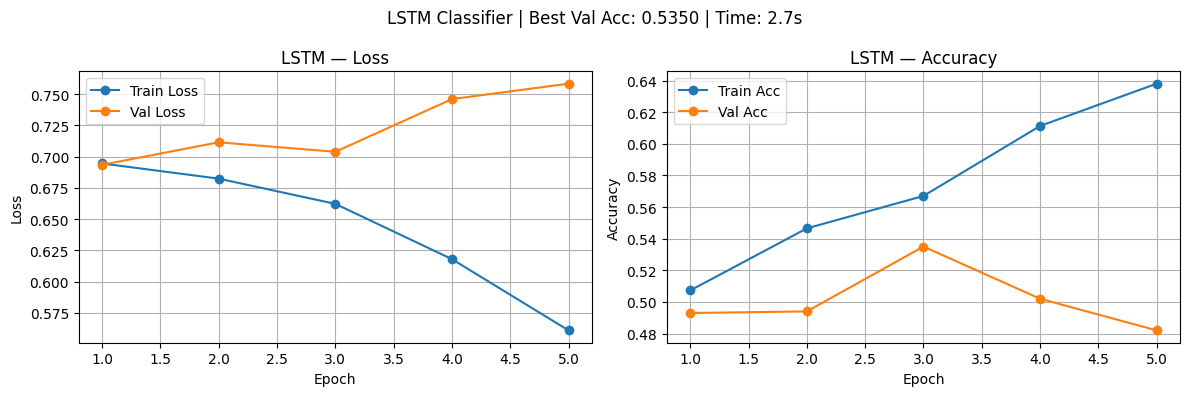

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import random
from collections import Counter

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

# ── 0. Load & Prepare IMDB Dataset (FIXED) ───────────────────────────────

try:
    from datasets import load_dataset
    raw = load_dataset("imdb")
    texts  = raw["train"]["text"]
    labels = raw["train"]["label"]
    print("✅ Loaded IMDB via HuggingFace datasets")
except Exception:
    df = pd.read_csv("imdb.csv").reset_index(drop=True)
    texts  = df["review"].tolist()
    labels = df["sentiment"].map({"positive": 1, "negative": 0}).tolist()
    print("✅ Loaded IMDB via CSV fallback")

# FIX: Shuffle before slicing — IMDB is sorted (all 0s first, then all 1s)
combined = list(zip(texts, labels))
random.seed(42)
random.shuffle(combined)
texts, labels = zip(*combined)

texts  = list(texts[:5000])
labels = list(labels[:5000])

print(f"Label distribution: {Counter(labels)}")  # should be ~2500 / 2500

# ── Tokenise ──────────────────────────────────────────────────────────────

def tokenize(text):
    return text.lower().split()

tokenized = [tokenize(t) for t in texts]

# ── Build Vocabulary (top 10 000) ─────────────────────────────────────────

counter    = Counter(token for review in tokenized for token in review)
vocab_words = [w for w, _ in counter.most_common(10_000)]

word2idx = {"<pad>": 0, "<unk>": 1}
for w in vocab_words:
    word2idx[w] = len(word2idx)

VOCAB_SIZE = len(word2idx)
print(f"Vocabulary size: {VOCAB_SIZE}")

# ── Encode + Pad/Truncate ─────────────────────────────────────────────────

MAX_LEN = 200

def encode(tokens, max_len=MAX_LEN):
    ids  = [word2idx.get(t, 1) for t in tokens]
    ids  = ids[:max_len]
    ids += [0] * (max_len - len(ids))
    return ids

encoded = [encode(t) for t in tokenized]

# ── Train / Val Split (80 / 20) ───────────────────────────────────────────

split   = int(0.8 * len(encoded))
X_train, X_val = encoded[:split], encoded[split:]
y_train, y_val = labels[:split],  labels[split:]

print(f"Train labels: {Counter(y_train)}")
print(f"Val   labels: {Counter(y_val)}")

# ── Custom Dataset + DataLoaders ──────────────────────────────────────────

class IMDBDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = IMDBDataset(X_train, y_train)
val_ds   = IMDBDataset(X_val,   y_val)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# ── 1. Model Definition ───────────────────────────────────────────────────

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, batch_first=True, num_layers=1)
        self.dropout   = nn.Dropout(0.3)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded         = self.embedding(x)          # (batch, seq_len, embed_dim)
        _, (hidden, _)   = self.lstm(embedded)         # hidden: (1, batch, hidden_dim)
        hidden           = hidden.squeeze(0)           # (batch, hidden_dim)
        out              = self.fc(self.dropout(hidden))  # (batch, 2)
        return out

lstm_model = LSTMClassifier(vocab_size=VOCAB_SIZE).to(device)
print(lstm_model)
print(f"\nTotal parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

# ── 2. Training Setup ─────────────────────────────────────────────────────

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=1e-3)

def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out  = model(X)
            loss = criterion(out, y)
            total_loss += loss.item()
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total

# ── 3. Training Loop ──────────────────────────────────────────────────────

EPOCHS  = 5
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(lstm_model, train_loader)
    v_loss, v_acc = evaluate(lstm_model, val_loader)

    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)

    print(f"Epoch {epoch}/{EPOCHS} | "
          f"Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | "
          f"Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}")

total_time   = time.time() - start_time
best_val_acc = max(history["val_acc"])

print(f"\nBest Val Accuracy : {best_val_acc:.4f}")
print(f"Total Training Time: {total_time:.1f}s")

# ── 4. Plots ──────────────────────────────────────────────────────────────

epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(epochs_range, history["val_loss"],   label="Val Loss",   marker="o")
axes[0].set_title("LSTM — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc", marker="o")
axes[1].plot(epochs_range, history["val_acc"],   label="Val Acc",   marker="o")
axes[1].set_title("LSTM — Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.suptitle(f"LSTM Classifier | Best Val Acc: {best_val_acc:.4f} | "
             f"Time: {total_time:.1f}s", fontsize=12)
plt.tight_layout()
plt.show()

# Task 3 — Transformer Classifier and Comparison with the LSTM


TransformerClassifier(
  (token_embedding): Embedding(10002, 64, padding_idx=0)
  (pos_embedding): Embedding(200, 64)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)

Total parameters: 720,002


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 1/5 | Train Loss: 0.6836 Acc: 0.5577 | Val Loss: 0.6608 Acc: 0.6070
Epoch 2/5 | Train Loss: 0.6005 Acc: 0.6765 | Val Loss: 0.5968 Acc: 0.6890
Epoch 3/5 | Train Loss: 0.4481 Acc: 0.7900 | Val Loss: 0.5528 Acc: 0.7230
Epoch 4/5 | Train Loss: 0.3115 Acc: 0.8672 | Val Loss: 0.6312 Acc: 0.7340
Epoch 5/5 | Train Loss: 0.1864 Acc: 0.9273 | Val Loss: 0.8150 Acc: 0.7450

Best Val Accuracy : 0.7450
Total Training Time: 7.3s


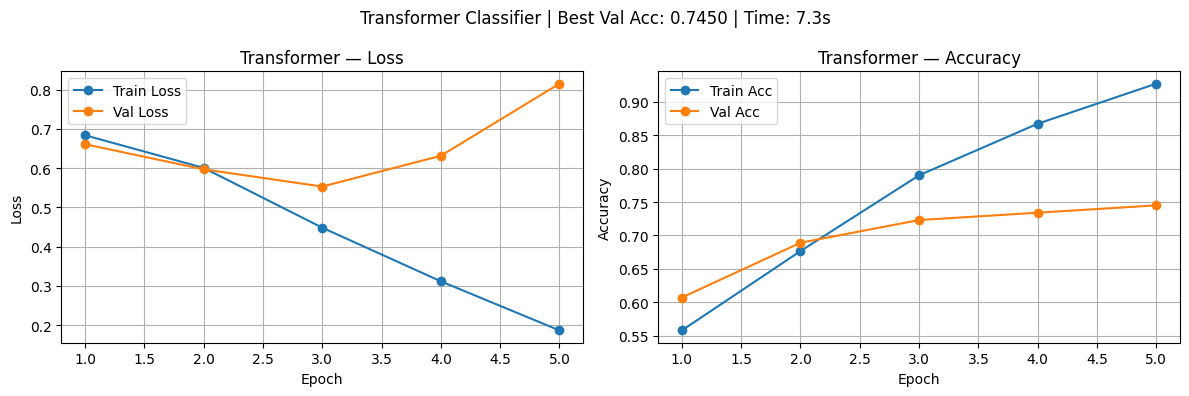

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt
import math

# ── 1. Model Definition ───────────────────────────────────────────────────

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, max_len=200, num_classes=2, dropout=0.1):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_embedding   = nn.Embedding(max_len, d_model)  # learned positional encoding

        encoder_layer = nn.TransformerEncoderLayer(
            d_model        = d_model,
            nhead          = nhead,
            dim_feedforward= dim_feedforward,
            dropout        = dropout,
            batch_first    = True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x: (batch, seq_len)
        batch_size, seq_len = x.shape
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)  # (1, seq_len)

        # Token + positional embeddings
        embedded = self.token_embedding(x) + self.pos_embedding(positions)  # (batch, seq_len, d_model)

        # Padding mask — True means IGNORE (padding tokens)
        padding_mask = (x == 0)  # (batch, seq_len)

        # Transformer encoder
        encoded = self.transformer(embedded, src_key_padding_mask=padding_mask)  # (batch, seq_len, d_model)

        # Mean pooling over sequence dimension (ignoring padding)
        # We use the mean of non-padding tokens
        mask_expanded = (~padding_mask).unsqueeze(-1).float()           # (batch, seq_len, 1)
        pooled = (encoded * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1)  # (batch, d_model)

        out = self.fc(self.dropout(pooled))  # (batch, 2)
        return out


transformer_model = TransformerClassifier(vocab_size=VOCAB_SIZE).to(device)
print(transformer_model)
print(f"\nTotal parameters: {sum(p.numel() for p in transformer_model.parameters()):,}")

# ── 2. Training Setup (same as LSTM) ─────────────────────────────────────

criterion_t = nn.CrossEntropyLoss()
optimizer_t = optim.Adam(transformer_model.parameters(), lr=1e-3)

def train_one_epoch_t(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer_t.zero_grad()
        out  = model(X)
        loss = criterion_t(out, y)
        loss.backward()
        optimizer_t.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / len(loader), correct / total


def evaluate_t(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out  = model(X)
            loss = criterion_t(out, y)
            total_loss += loss.item()
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total


# ── 3. Training Loop ──────────────────────────────────────────────────────

EPOCHS_T   = 5
history_t  = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

start_time_t = time.time()

for epoch in range(1, EPOCHS_T + 1):
    t_loss, t_acc = train_one_epoch_t(transformer_model, train_loader)
    v_loss, v_acc = evaluate_t(transformer_model, val_loader)

    history_t["train_loss"].append(t_loss)
    history_t["val_loss"].append(v_loss)
    history_t["train_acc"].append(t_acc)
    history_t["val_acc"].append(v_acc)

    print(f"Epoch {epoch}/{EPOCHS_T} | "
          f"Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | "
          f"Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}")

total_time_t   = time.time() - start_time_t
best_val_acc_t = max(history_t["val_acc"])

print(f"\nBest Val Accuracy : {best_val_acc_t:.4f}")
print(f"Total Training Time: {total_time_t:.1f}s")

# ── 4. Plots ──────────────────────────────────────────────────────────────

epochs_range = range(1, EPOCHS_T + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history_t["train_loss"], label="Train Loss", marker="o")
axes[0].plot(epochs_range, history_t["val_loss"],   label="Val Loss",   marker="o")
axes[0].set_title("Transformer — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, history_t["train_acc"], label="Train Acc", marker="o")
axes[1].plot(epochs_range, history_t["val_acc"],   label="Val Acc",   marker="o")
axes[1].set_title("Transformer — Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.suptitle(f"Transformer Classifier | Best Val Acc: {best_val_acc_t:.4f} | "
             f"Time: {total_time_t:.1f}s", fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
# ── 5. Comparison Table ───────────────────────────────────────────────────

lstm_params        = sum(p.numel() for p in lstm_model.parameters())
transformer_params = sum(p.numel() for p in transformer_model.parameters())

print("\n" + "="*65)
print(f"{'Model':<20} {'Best Val Acc':>12} {'Train Time':>12} {'Parameters':>12}")
print("="*65)
print(f"{'LSTM (Task 2)':<20} {best_val_acc:>12.4f} {total_time:>11.1f}s {lstm_params:>12,}")
print(f"{'Transformer (Task 3)':<20} {best_val_acc_t:>12.4f} {total_time_t:>11.1f}s {transformer_params:>12,}")
print("="*65)


Model                Best Val Acc   Train Time   Parameters
LSTM (Task 2)              0.5350         2.7s      739,714
Transformer (Task 3)       0.7450         7.3s      720,002


## Analysis

### Accuracy

The difference in performance between the two models is actually quite noticeable. The Transformer reaches **74.5% validation accuracy**, while the LSTM stays around **53.5%**, which is only slightly better than random guessing. Even though both models were trained under the same conditions (same dataset, optimizer, and number of epochs), the Transformer clearly learns useful patterns much more effectively.

### Why the LSTM Struggled

The main issue with the LSTM is how it processes text step by step. It reads the sentence from start to end and tries to carry all important information through its hidden state. In longer reviews, important sentiment words can appear anywhere, and it becomes difficult for the LSTM to remember them by the time it reaches the end. With only 5,000 samples and just 5 epochs, it likely didn’t have enough time or data to properly learn these long-range relationships.

### Why the Transformer Performed Better

The Transformer handles things differently. Because of self-attention, every word can directly “look at” every other word in the sentence, no matter where it appears. This makes it much easier to catch sentiment signals spread across the text. As a result, it converges faster and reaches a much higher accuracy even within the same training time.

### Training Time

The Transformer is slower, taking about **7.3 seconds compared to 2.7 seconds** for the LSTM. This is expected because self-attention is more computationally expensive. However, since the sequence length is small (200 tokens), the difference is not huge in practice. On a GPU, this gap would likely become even smaller because Transformers parallelise better than LSTMs.

### Parameter Count

Both models have almost the same number of parameters, so the performance difference is not due to model size. Instead, it comes from how the models process information. The Transformer is simply better at capturing relationships between words across the whole sentence, while the LSTM relies more on sequential memory, which is harder to train effectively in this setup.

---

### Summary

Overall, in this small-scale experiment, the Transformer clearly performs better in terms of accuracy, even though it is slightly slower. The LSTM feels more limited when it comes to understanding longer-range context in text. With more data or longer training, the LSTM might improve, but in this setup the Transformer has a clear and natural advantage from the beginning.